In [78]:
import numpy as np
import os


In [79]:
# run_dir = '/Users/akap5486/Projects/groundwater/data/henry_data/one_coupling_scenario/scenario_beta0.200_diffc0.00140/run_000001_hk864.00_por0.350_in2.8510_ghb1.0000'
# run_dir = '/Users/akap5486/Projects/groundwater/data/henry_data/grid_scenarios_20x40/scenarios/scenario_01/run_000001/'
run_dir = os.path.expanduser('~/Projects/groundwater/data/henry_data/grid_scenarios_dynamic_storage_20x40/scenarios/scenario_16/run_000003/')
# run_dir = os.path.expanduser('~/Projects/groundwater/data/henry_data/grid_scenarios_high_freq_20x40/scenarios/scenario_01/run_000003/')

In [80]:
windows = np.load(run_dir + '/windows.npz')
windows.files

['input_tensor',
 'output_tensor',
 'input_channel_names',
 't_index',
 't_lag_index',
 'time_t',
 'time_t_lag',
 'window_ids',
 'lag',
 'ncol',
 'nlay',
 'total_time',
 'nstp',
 'beta_c',
 'diffc',
 'hk',
 'por',
 'inflow',
 'ghb_head',
 'al',
 'at',
 'cinlet',
 'init_mode',
 'initial_head',
 'initial_concentration']

In [81]:
windows['input_tensor'].shape, windows['output_tensor'].shape

((49, 7, 20, 40), (49, 2, 20, 40))

In [129]:
# Plot conc and head at the first time step of the input tensor
import matplotlib.pyplot as plt
def plot_input_output_at_idx(windows, idx=0):
    input_tensor = windows['input_tensor']
    channel_names = windows['input_channel_names']

    # Decode channel names if stored as bytes
    channel_names = [
        name.decode('utf-8') if isinstance(name, (bytes, np.bytes_)) else str(name)
        for name in channel_names
    ]

    channel_names_map = {'concentration_t': r"$C(t)$", 'head_t': r"$h(t)$",
                            "flux_left_boundary": r"$Q_{in}$",  "ghb_flux_right_boundary": r"$h_{tide}$",
                            "cinlet_right_boundary": r"$C_{in}$", "beta_c": r"$\beta_C$", "diffc": r"$D$"}

    n_channels = input_tensor.shape[1]
    n_cols = min(3, n_channels+2)
    n_rows = int(np.ceil((n_channels+2) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.2 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    
    x_range = (0, 8.0)
    z_range = (0, 4.0)

    for ch in range(n_channels):
        if ch == 0:
            cmap = 'Reds'
            axes[ch].set_title(f"{channel_names_map.get(channel_names[ch], channel_names[ch])}")
        elif ch == 1:
            cmap = 'Blues'
            axes[ch].set_title(f"{channel_names_map.get(channel_names[ch], channel_names[ch])}")
        else:
            cmap = 'Greens'
            if channel_names[ch] in ['beta_c', 'diffc']:
                title_str = f"{channel_names_map.get(channel_names[ch], channel_names[ch])} ({input_tensor[idx, ch, :, :].mean():.2f})"
            else:
                title_str = f"{channel_names_map.get(channel_names[ch], channel_names[ch])} ({input_tensor[idx, ch, :, :].min():.2f}-{input_tensor[idx, ch, :, :].max():.2f})" if ch < len(channel_names) else f'Channel {ch}'
            axes[ch].set_title(title_str)

        im = axes[ch].imshow(input_tensor[idx, ch, :, :], origin='upper', cmap=cmap, extent=[x_range[0], x_range[1], z_range[1], z_range[0]])
        fig.colorbar(im, ax=axes[ch])



    # # Hide any unused subplot axes
    # for k in range(n_channels, len(axes)):
    #     axes[k].axis('off')


    im0 = axes[n_channels].imshow(windows['output_tensor'][idx, 0, :, :], origin='upper', cmap='Reds', extent=[x_range[0], x_range[0], z_range[1], z_range[1]])
    axes[n_channels].set_title(r'$C(t+1)$')
    fig.colorbar(im0, ax=axes[n_channels])

    im1 = axes[n_channels + 1].imshow(windows['output_tensor'][idx, 1, :, :], origin='upper', cmap='Blues', extent=[x_range[0], x_range[0], z_range[1], z_range[1]])
    axes[n_channels + 1].set_title(r'$h(t+1)$')
    fig.colorbar(im1, ax=axes[n_channels + 1])

    plt.tight_layout()
    plt.show()

In [130]:
plot_input_output_at_idx(windows, idx=22)

BadZipFile: Bad CRC-32 for file 'input_tensor.npy'

In [131]:
plot_input_output_at_idx(windows, idx=48)

BadZipFile: Bad CRC-32 for file 'input_tensor.npy'

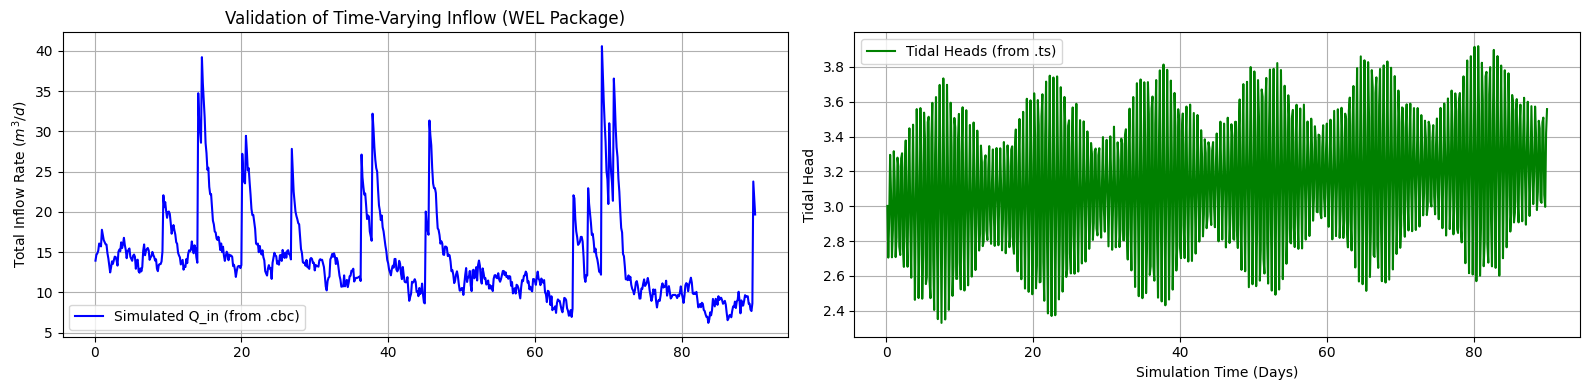

In [161]:
import flopy.utils.binaryfile as bf
import matplotlib.pyplot as plt
import numpy as np
import os

# single_run_dir = os.path.expanduser('~/Projects/groundwater/data/henry_data/one_coupling_scenario/scenario_beta0.700_diffc0.57024/run_000001_in2.8750_')
# single_run_dir = os.path.expanduser('~/Projects/groundwater/data/henry_data/one_coupling_scenario/scenario_beta0.700_diffc0.57024/run_000001_in28.7500_')
single_run_dir = os.path.expanduser('~/Projects/groundwater/data/henry_data/one_coupling_scenario/scenario_beta0.700_diffc0.57024/run_000001_in14.2610_')


# 1. Point to your Cell-by-Cell file (update the filename to match your model name)
cbc_file = os.path.join(single_run_dir, "gwf.cbc") 

# 2. Open the binary budget file (MODFLOW 6 outputs in double precision)
cbc_obj = bf.CellBudgetFile(cbc_file, precision='double')

# 3. Get the list of all simulation times saved in the file
times = cbc_obj.get_times()

# 4. Extract the WEL package data
# Note: The text parameter usually matches the package name. If 'WEL' returns empty, 
# you can use cbc_obj.get_unique_record_names() to find the exact string.
wel_data = cbc_obj.get_data(text='WEL') 

# 5. Loop through the data to calculate total inflow per time step
actual_qin = []
for step_data in wel_data:
    # step_data is a numpy recarray containing ['node', 'q', etc.]
    # We sum the 'q' (flux) for all cells in the well boundary for this time step
    total_flux = np.sum(step_data['q']) 
    actual_qin.append(total_flux)

tide_heads = []

# Tidal heads time-series
tides_ts = os.path.join(single_run_dir, 'ghb_ts.ts')

with open(tides_ts, 'r') as f:
    ts_line = None
    for line in f.readlines():
        if line.startswith('BEGIN timeseries'):
            ts_line = True
            continue
        if line.startswith('END timeseries'):
            ts_line = False
            break

        if not ts_line:
            continue
        else:
            parts = line.split()
            if len(parts) >= 2:
                time = float(parts[0])
                head = float(parts[1])
                tide_heads.append(head)

# print("Extracted tidal heads:", np.array(tide_heads))

# 6. Plot the extracted fluxes and tide heads in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.plot(times, actual_qin, linestyle='-', color='b', label='Simulated Q_in (from .cbc)')
ax1.set_title("Validation of Time-Varying Inflow (WEL Package)")
ax1.set_ylabel("Total Inflow Rate ($m^3/d$)")
ax1.grid(True) 
ax1.legend()

ax2.plot(times, tide_heads[1:], linestyle='-', color='g', label='Tidal Heads (from .ts)')
ax2.set_xlabel("Simulation Time (Days)")
ax2.set_ylabel("Tidal Head")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


Text(0.5, 0, 'days')

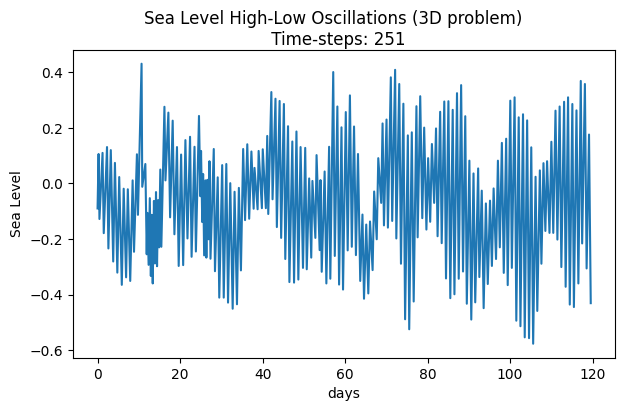

In [162]:
import pandas as pd
sea_level_hl_path = os.path.expanduser('~/OneDrive - The University of Sydney (Staff)/Shared/Data/FEFLOW/simulation_files/SeaLevelDataPeaksHL.csv')
sea_level_hl = pd.read_csv(sea_level_hl_path, names=['days', 'sea_level'])

sea_level_hl_30 = sea_level_hl.loc[sea_level_hl['days']<=120]


fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle(f'Sea Level High-Low Oscillations (3D problem) \n Time-steps: {len(sea_level_hl_30)}')

ax.plot(sea_level_hl_30['days'], sea_level_hl_30['sea_level'])
ax.set_ylabel('Sea Level')
ax.set_xlabel('days')

In [163]:
from numpy.lib import index_tricks
def plot_2d_field(data, title, cbar_label, cmap="plasma", figsize=None):
    if not isinstance(data, list):
        data = [data]
    if not isinstance(title, list):
        title = [title]
    if not isinstance(cbar_label, list):
        cbar_label = [cbar_label]
    if not isinstance(cmap, list):
        cmap = [cmap]
    
    n_plots = len(data)
    if figsize is None:
        figsize = (6 * n_plots, 4)
        
    fig, axes = plt.subplots(1, n_plots, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    x_range = (0, 8.0)
    z_range = (0, 4.0)
    
    for i in range(n_plots):
        ax = axes[i]
        im = ax.imshow(data[i], cmap=cmap[i], extent=[x_range[0], x_range[1], z_range[0], z_range[1]])
        ax.set_title(title[i], fontsize=12)
        ax.set_xlabel("Length (x-axis)", fontsize=10)
        ax.set_ylabel("Elevation (z-axis)", fontsize=10)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.6)
        cbar.set_label(cbar_label[i], fontsize=10)
        cbar.ax.tick_params(labelsize=9)
        # if x_ticks is not None and y_ticks is not None:
        #     ax.set_xticks(x_ticks)
        #     ax.set_yticks(y_ticks)   
    plt.tight_layout()
    plt.show()
    return fig, axes

In [164]:
npz_file = os.path.join(single_run_dir, "windows.npz")
windows = np.load(npz_file)
input_tensor = windows['input_tensor']
output_tensor = windows['output_tensor']

Coordinates: [[19, 10], [13, 5], [0, 0], [6, 39]]


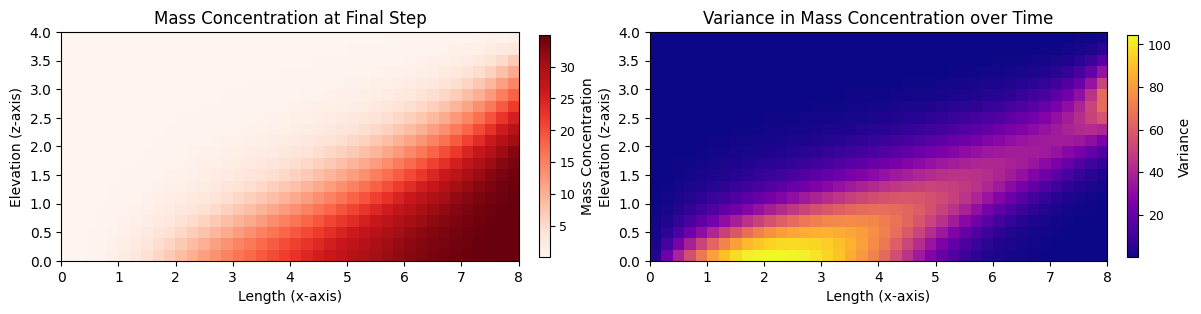

In [165]:
# Coords with max and min variance over time
mass_conc_at_final_step = output_tensor[-1, 0, :, :]  # shape (ny, nx)
var_over_time = output_tensor[:, 0].var(axis=0)  # shape (ny, nx)
flat_idx_var_order = np.argsort(var_over_time.ravel())[::-1]
flat_idx_var_select = np.concatenate([flat_idx_var_order[:1], flat_idx_var_order[[int(len(flat_idx_var_order)//2)]], flat_idx_var_order[-1:]])
coord_list_var = np.array([np.unravel_index(idx, var_over_time.shape) for idx in flat_idx_var_select])
coord_list_var = np.concatenate([coord_list_var, np.array([[6, 39]])])  # Combine with previous max-diff coords, ensuring no duplicates
print("Coordinates:", coord_list_var.tolist())

# Plot variance map using the reusable function
_ = plot_2d_field(
    [mass_conc_at_final_step, var_over_time],
    title=["Mass Concentration at Final Step", "Variance in Mass Concentration over Time"],
    cbar_label=["Mass Concentration", "Variance"],
    cmap=["Reds", "plasma"],
)

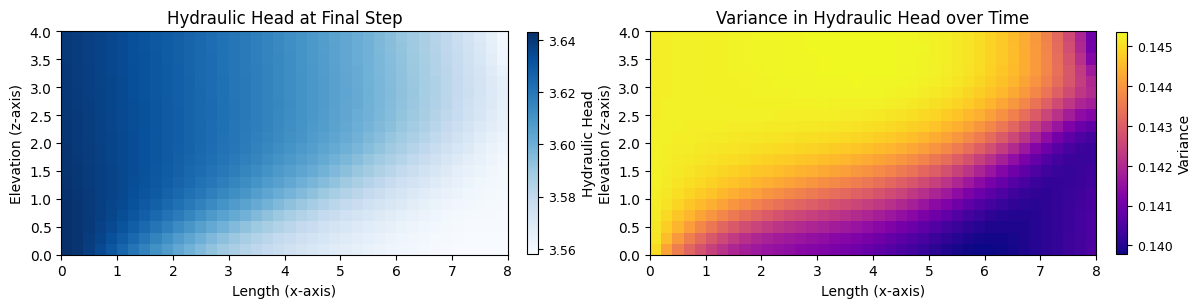

In [166]:
# Coords with max and min variance over time
hydraulic_head_at_final_step = output_tensor[-1, 1, :, :]  # shape (ny, nx)
head_var_over_time = output_tensor[:, 1].var(axis=0)  # shape (ny, nx)

# Plot variance map using the reusable function
_ = plot_2d_field(
    [hydraulic_head_at_final_step, head_var_over_time],
    title=["Hydraulic Head at Final Step", "Variance in Hydraulic Head over Time"],
    cbar_label=["Hydraulic Head", "Variance"],
    cmap=["Blues", "plasma"]
)

In [167]:
def plot_time_series_by_coords(coords, output_tensor, var_idx=0):

    fig, axes = plt.subplots(len(coords), 1, figsize=(6, 2 * len(coords)), squeeze=False)
    axes = axes.flatten()

    if var_idx == 0:
        var_name = 'Mass Concentration'
    elif var_idx == 1:
        var_name = 'Hydraulic Head'

    x_range = (0, 8.0)
    z_range = (0, 4.0)

    _, _, z_len, x_len = output_tensor.shape

    x_coords = np.linspace(x_range[0], x_range[1], x_len)
    z_coords = np.linspace(z_range[0], z_range[1], z_len)[::-1]
    

    for coord_idx, coord in enumerate(coords):
        ax = axes[coord_idx]
        ax.plot(times[-output_tensor.shape[0]:], output_tensor[:, var_idx, coord[0], coord[1]], marker='o', label=f"obs", markersize=2, linewidth=1)
        ax.set_title(f"{var_name} at (z={z_coords[coord[0]]:.2f}, x={x_coords[coord[1]]:.2f}) Over Time", fontsize=10)
        ax.set_xlabel("Time (days)", fontsize=10)
        ax.set_ylabel(f"{var_name}", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(title="Model Size", fontsize=9, loc="upper right")

    plt.tight_layout()
    plt.show()

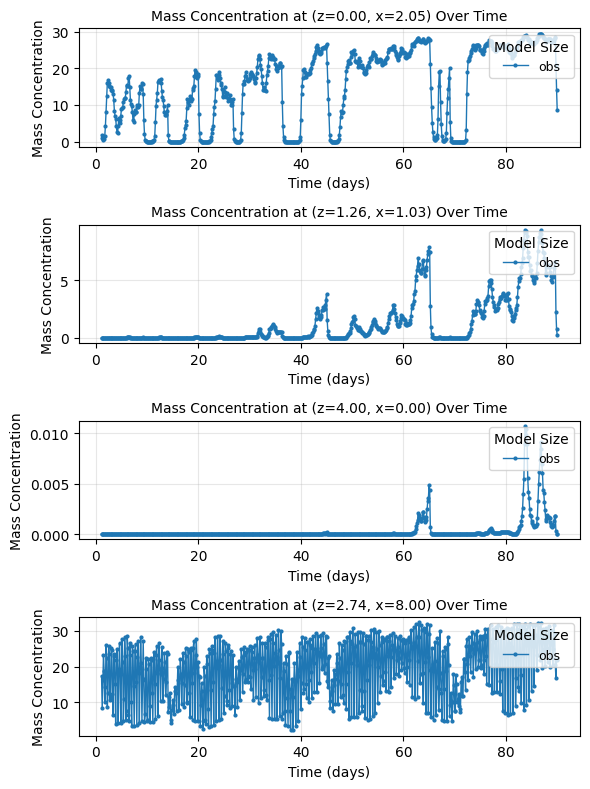

In [168]:
plot_time_series_by_coords(coord_list_var, output_tensor)

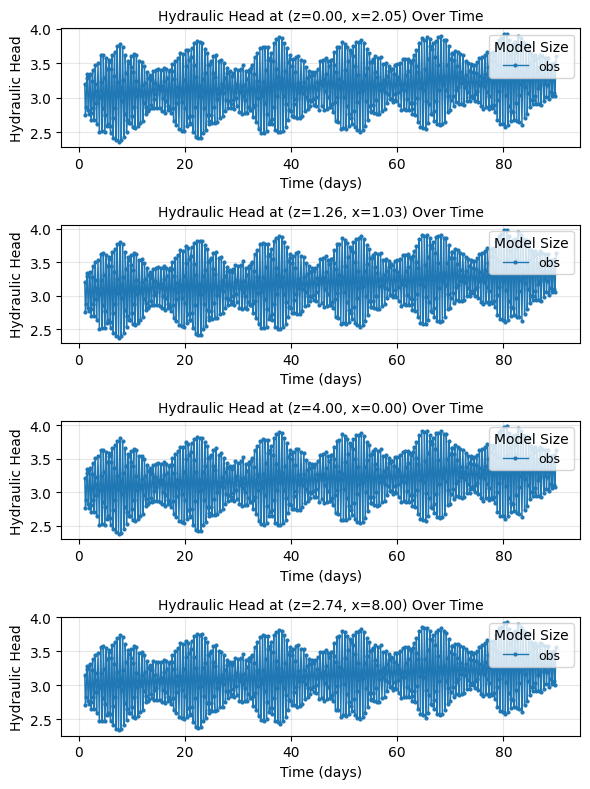

In [169]:
plot_time_series_by_coords(coord_list_var, output_tensor, var_idx=1)